# Diabetes Prediction Model
> Random Forest · XGBoost · Naive Bayes | ~100K patient records

**Pipeline:**
1. Setup & Imports
2. Load & Inspect Data
3. EDA (Univariate → Bivariate → Trivariate)
4. Preprocessing (encoding, scaling, resampling)
5. Model Training (RF, XGBoost, Naive Bayes)
6. Evaluation & Comparison
7. Save Best Model
8. Deploy with Gradio UI + API

## Installing Dependencies

In [1]:
!pip install -q xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib flask flask-ngrok

##Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('✅ All imports successful')

✅ All imports successful


##Load Dataset

In [3]:
# Upload CSV
from google.colab import files
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv
Dataset shape : (100000, 9)
Columns       : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Data Quality Check

In [4]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicates ===')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n=== Target Distribution ===')
print(df['diabetes'].value_counts())
print(f'Class imbalance ratio: {df["diabetes"].value_counts()[0] / df["diabetes"].value_counts()[1]:.2f}:1')

print('\n=== Basic Statistics ===')
df.describe()

=== Shape ===
(100000, 9)

=== Data Types ===
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

=== Missing Values ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

=== Duplicates ===
Duplicate rows: 3854

=== Target Distribution ===
diabetes
0    91500
1     8500
Name: count, dtype: int64
Class imbalance ratio: 10.76:1

=== Basic Statistics ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


## Univariate Analysis

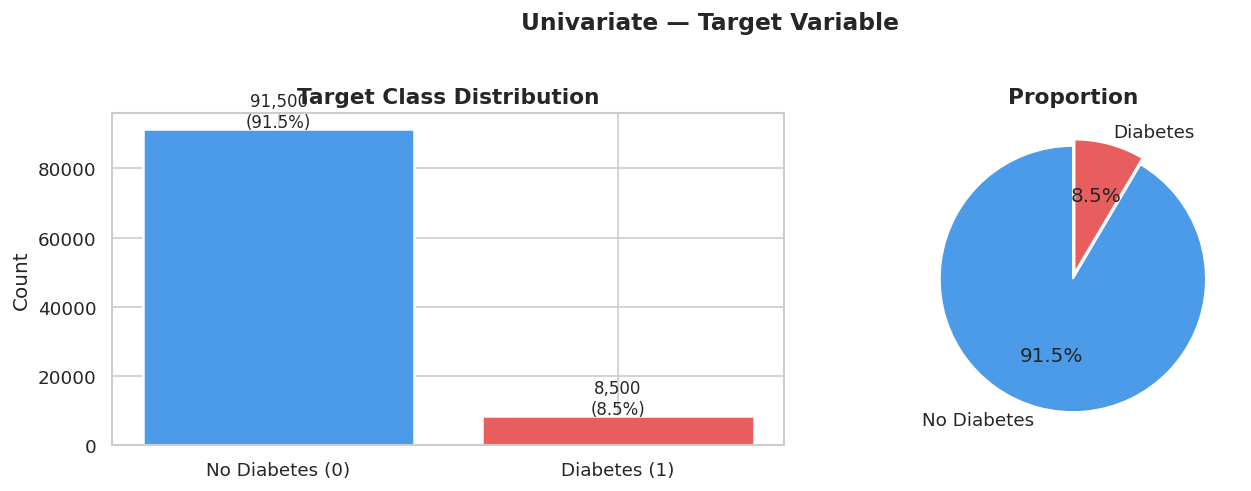

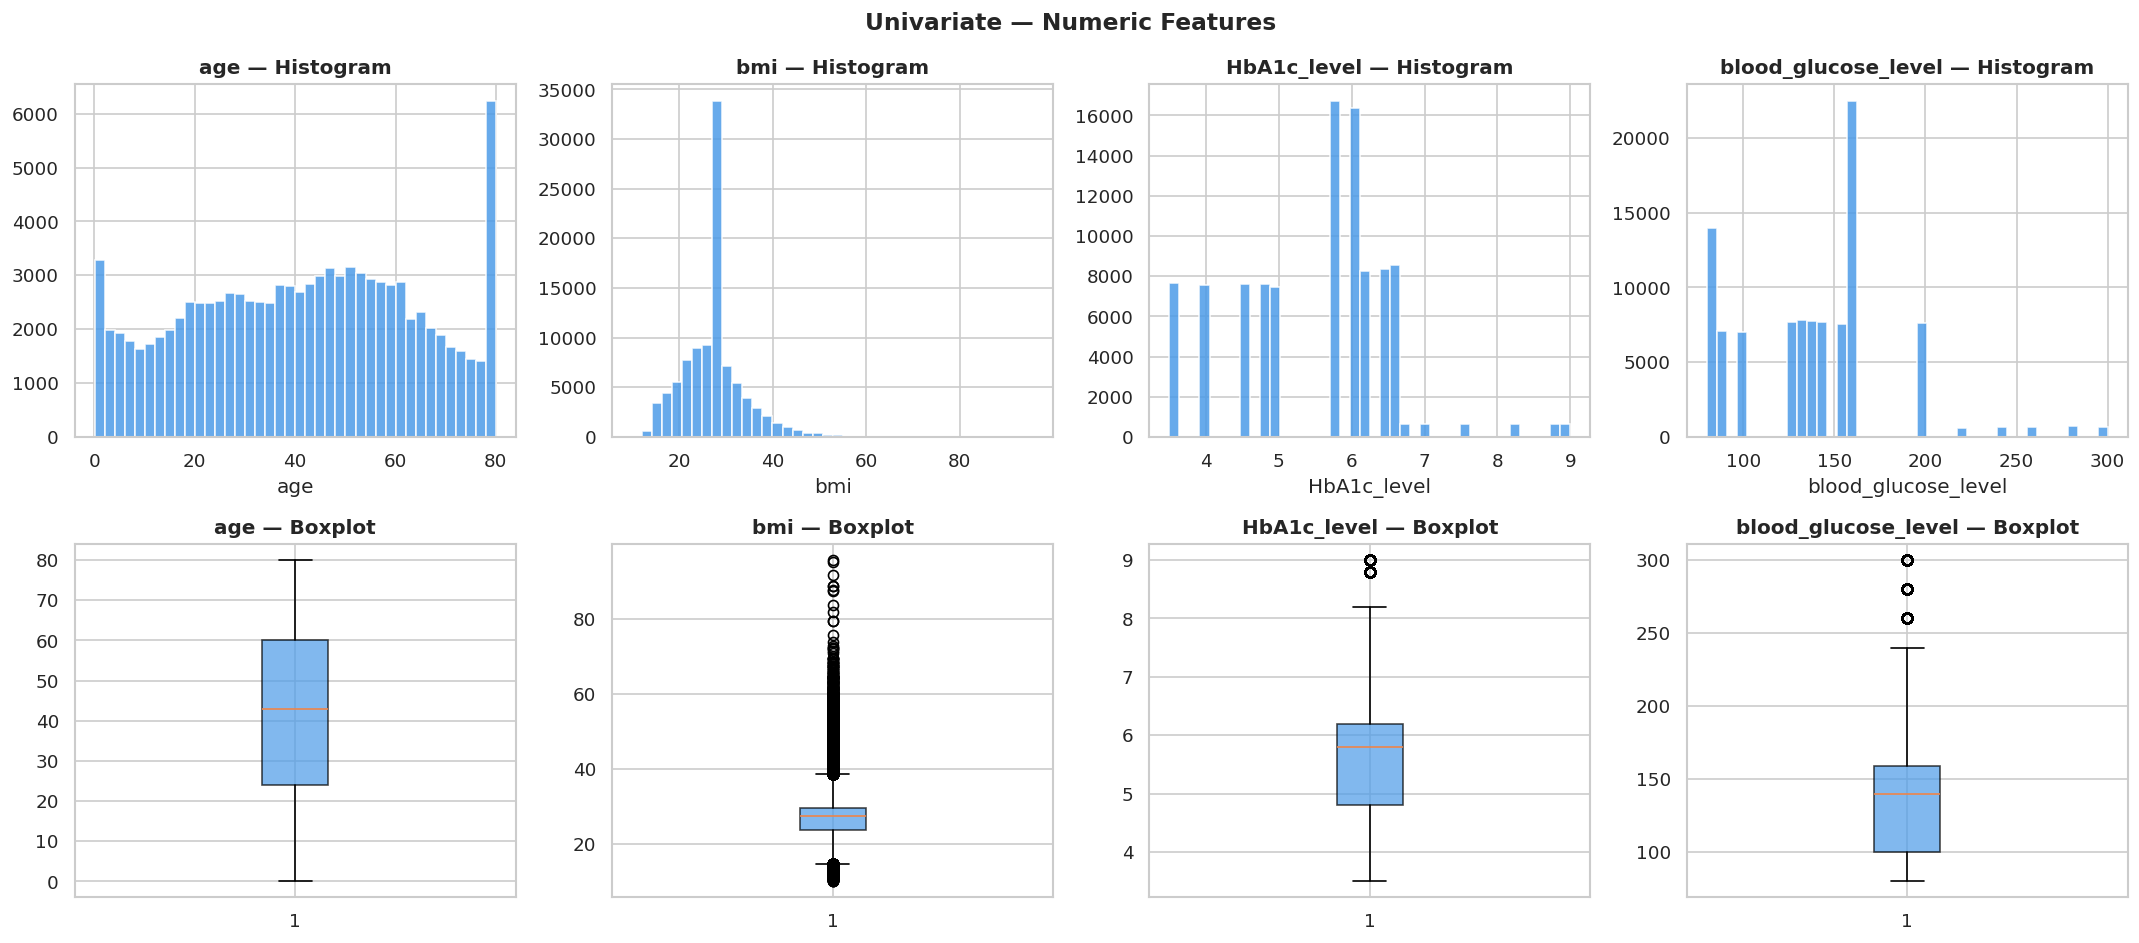

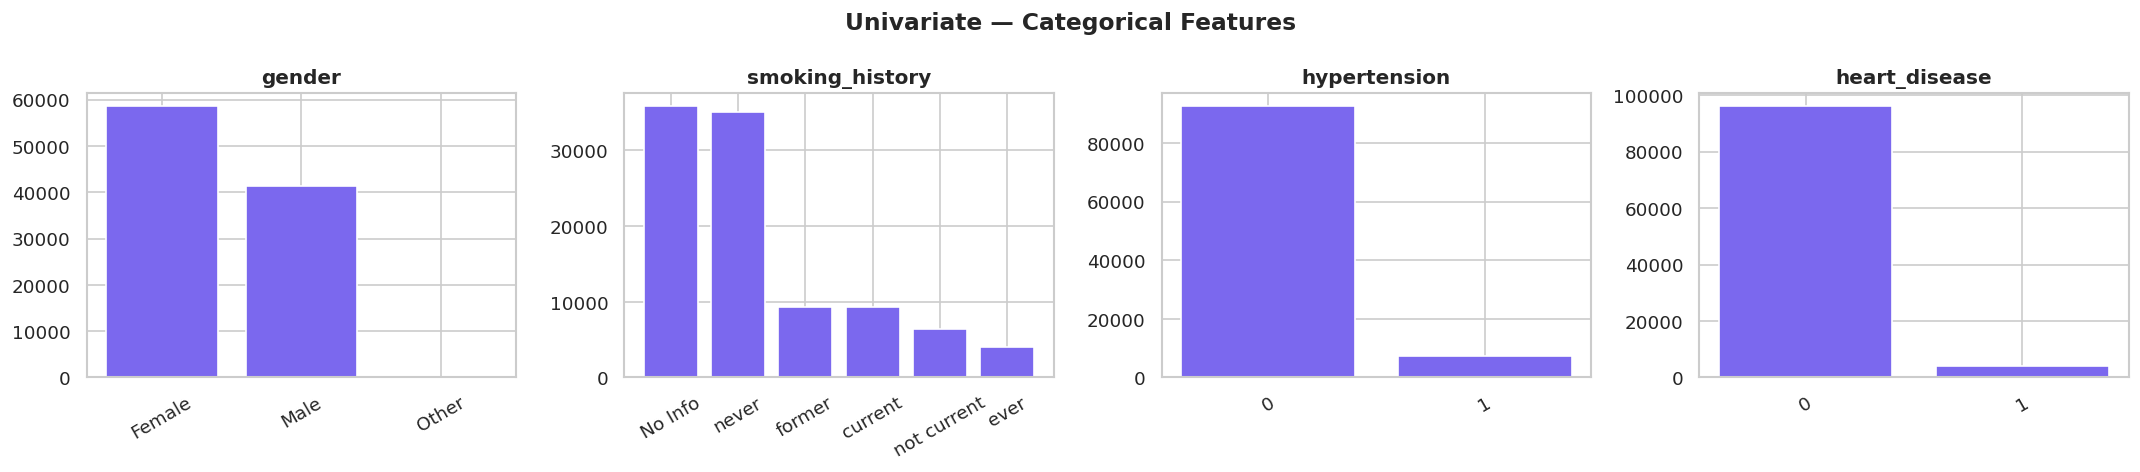

In [5]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['diabetes'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#4C9BE8', '#E85D5D'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            colors=['#4C9BE8', '#E85D5D'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Univariate — Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Numeric feature distributions
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=40, color='#4C9BE8', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Histogram', fontweight='bold')
    axes[0, i].set_xlabel(col)

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='#4C9BE8', alpha=0.7))
    axes[1, i].set_title(f'{col} — Boxplot', fontweight='bold')

plt.suptitle('Univariate — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Categorical features
cat_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].bar(vc.index.astype(str), vc.values, color='#7B68EE', edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Univariate — Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bivariate Analysis

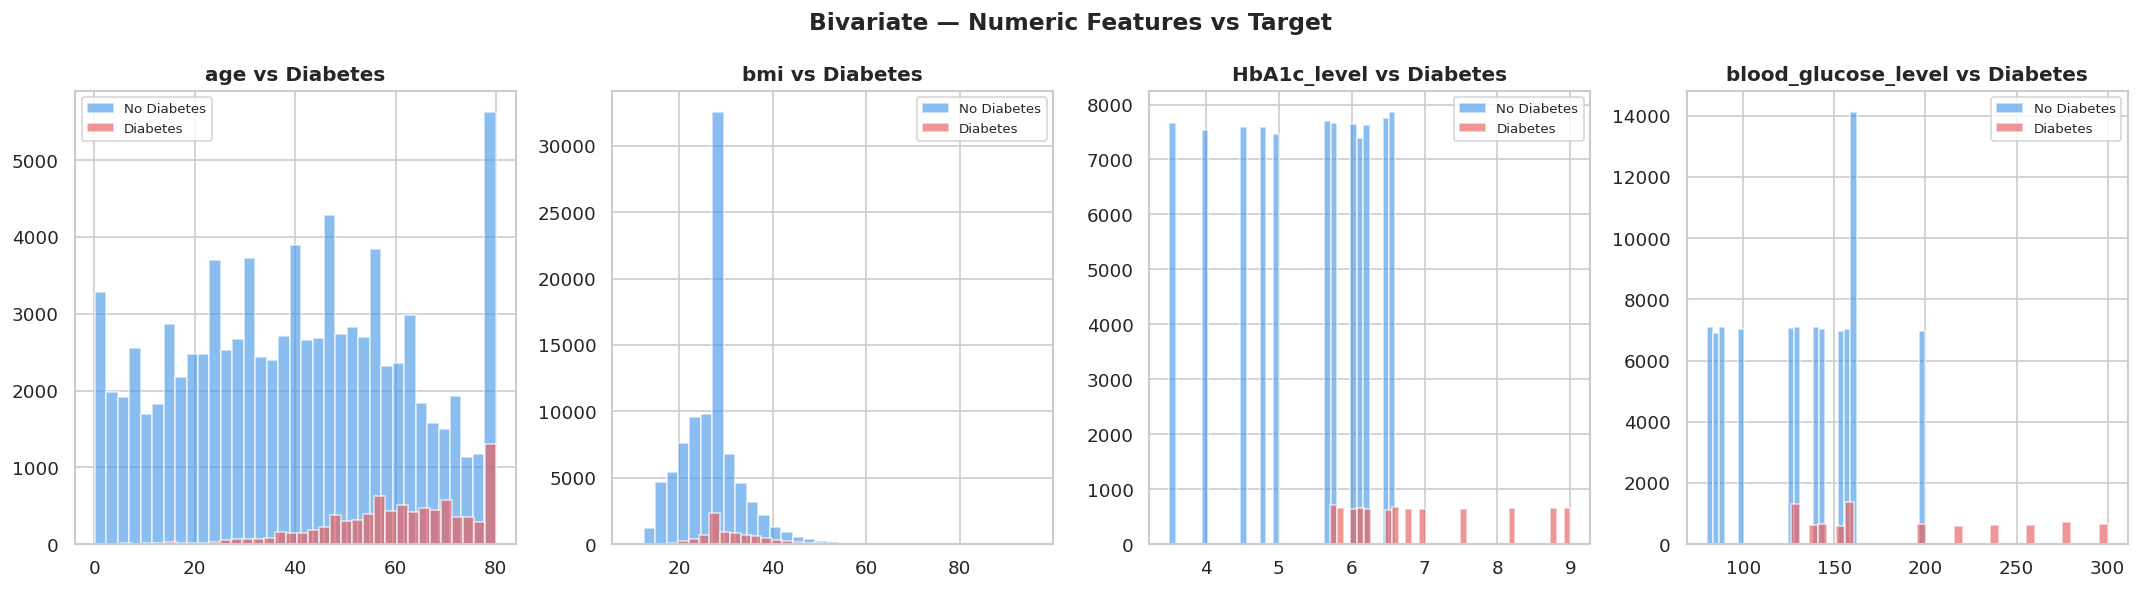

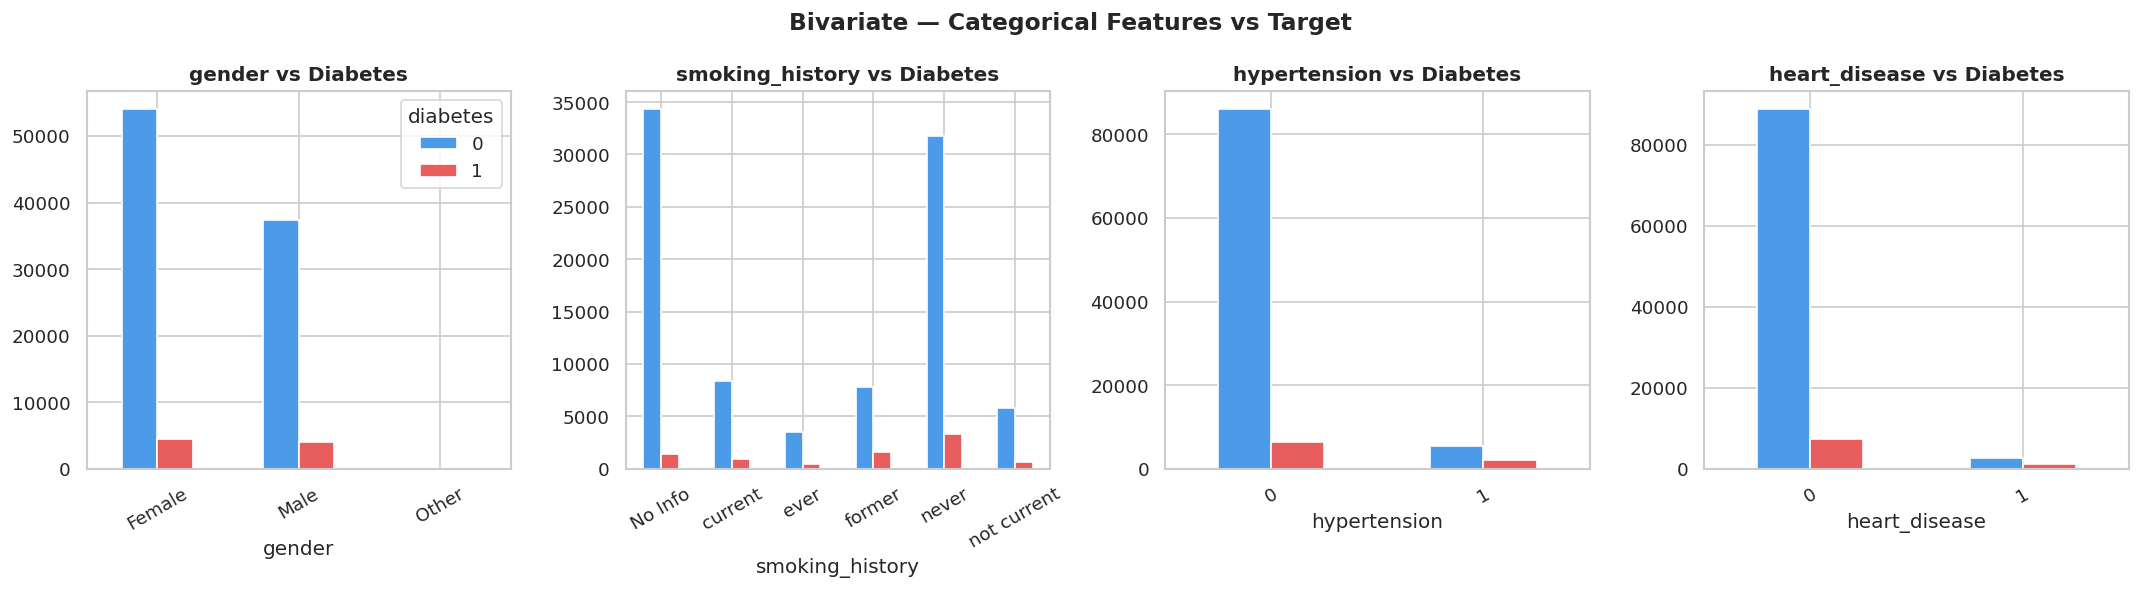

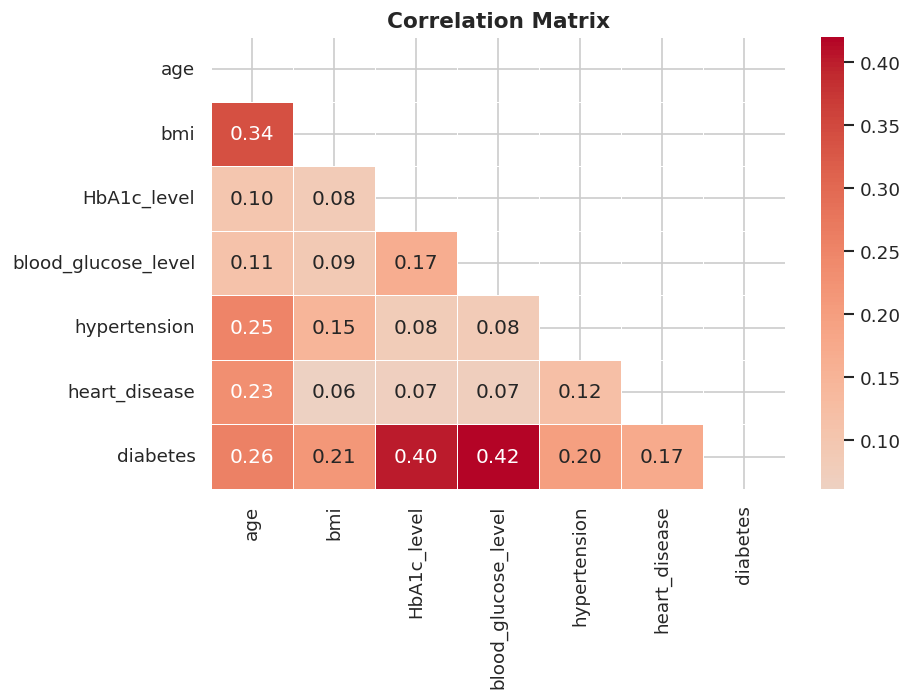

In [6]:
# Numeric features vs target
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#4C9BE8', '#E85D5D']):
        axes[i].hist(df[df['diabetes'] == label][col], bins=35,
                     alpha=0.65, color=color,
                     label='No Diabetes' if label == 0 else 'Diabetes',
                     edgecolor='white')
    axes[i].set_title(f'{col} vs Diabetes', fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Bivariate — Numeric Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Categorical features vs target
cat_cols = ['gender', 'smoking_history', 'hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'diabetes']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#4C9BE8', '#E85D5D'],
            edgecolor='white', legend=(i == 0))
    axes[i].set_title(f'{col} vs Diabetes', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Bivariate — Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric only)
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols + ['hypertension', 'heart_disease', 'diabetes']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Trivariate Analysis

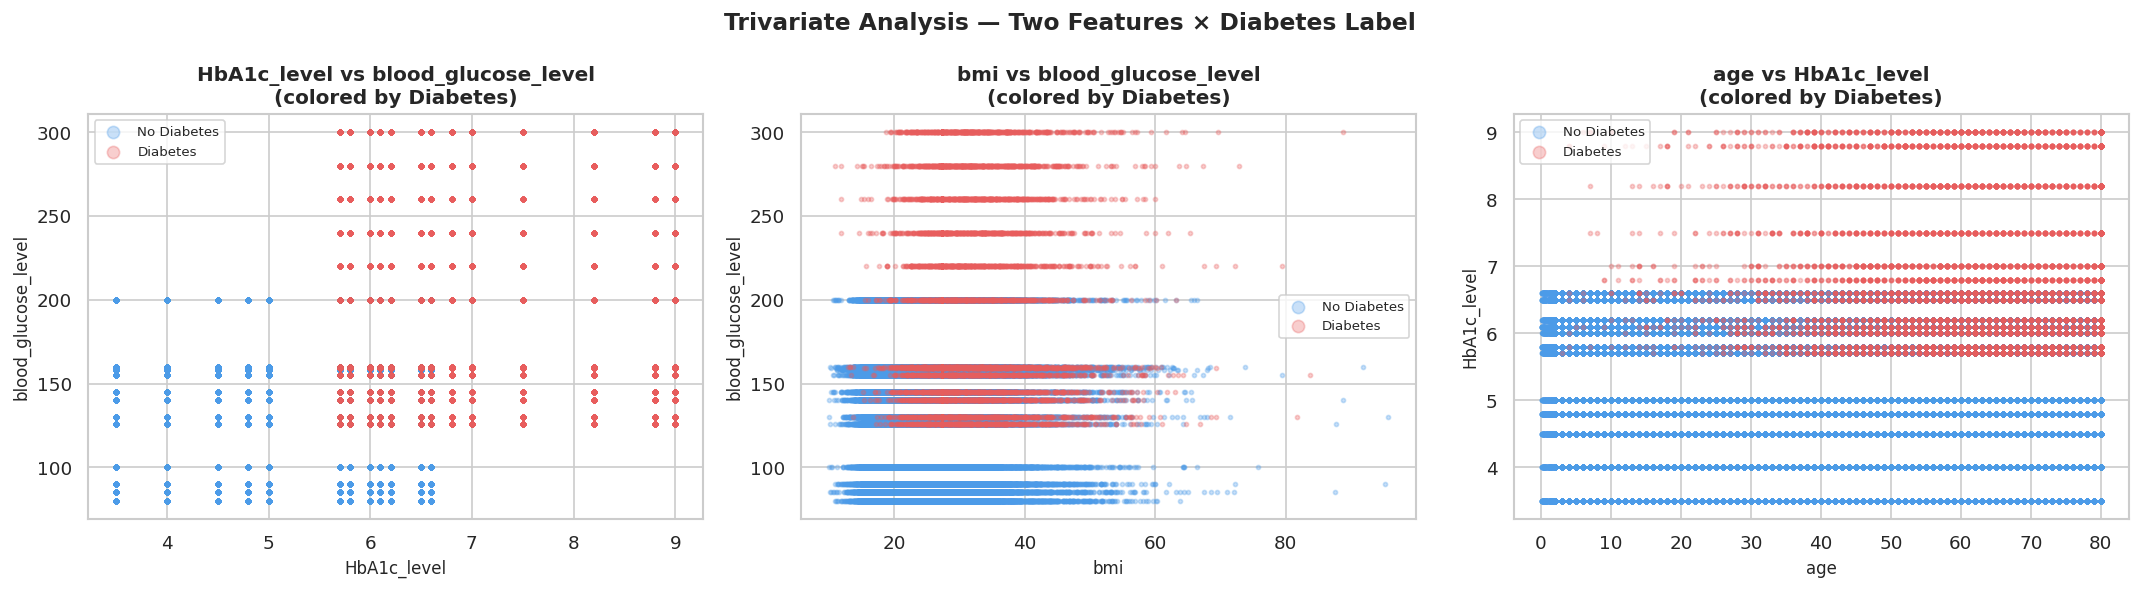

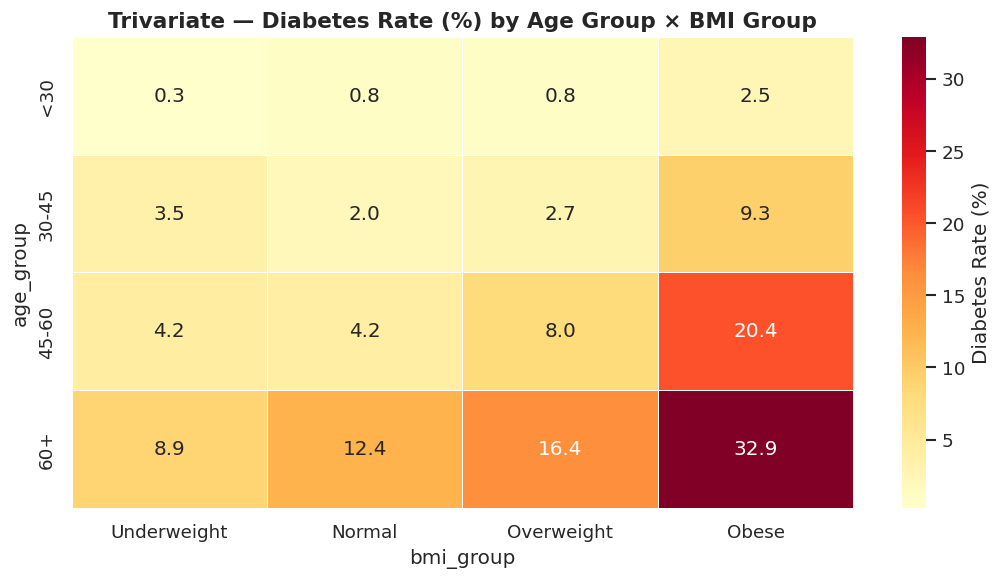

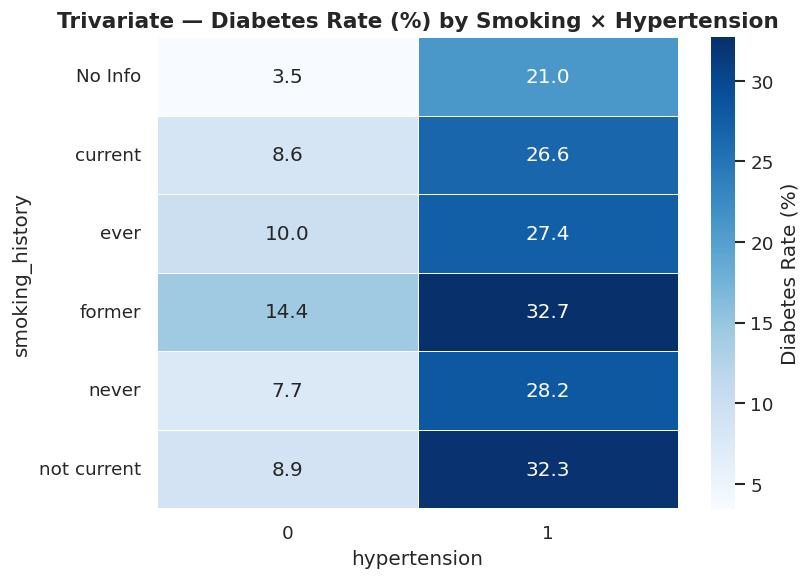

In [7]:
# HbA1c vs Blood Glucose vs Diabetes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y) in zip(axes, [
    ('HbA1c_level', 'blood_glucose_level'),
    ('bmi', 'blood_glucose_level'),
    ('age', 'HbA1c_level')
]):
    for label, color, name in zip([0, 1], ['#4C9BE8', '#E85D5D'],
                                   ['No Diabetes', 'Diabetes']):
        subset = df[df['diabetes'] == label]
        ax.scatter(subset[x], subset[y], alpha=0.3, s=6,
                   color=color, label=name)
    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.set_title(f'{x} vs {y}\n(colored by Diabetes)', fontweight='bold')
    ax.legend(markerscale=3, fontsize=8)

plt.suptitle('Trivariate Analysis — Two Features × Diabetes Label',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Age group × BMI group × Diabetes rate
df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,100],
                          labels=['<30', '30-45', '45-60', '60+'])
df['bmi_group'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100],
                          labels=['Underweight','Normal','Overweight','Obese'])

pivot = df.pivot_table(values='diabetes', index='age_group',
                        columns='bmi_group', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Diabetes Rate (%)'})
ax.set_title('Trivariate — Diabetes Rate (%) by Age Group × BMI Group',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Smoking × Hypertension × Diabetes rate
pivot2 = df.pivot_table(values='diabetes', index='smoking_history',
                         columns='hypertension', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Diabetes Rate (%)'})
ax.set_title('Trivariate — Diabetes Rate (%) by Smoking × Hypertension',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# drop temp columns
df.drop(columns=['age_group', 'bmi_group'], inplace=True)

## Preprocessing

In [8]:
df_processed = df.copy()

# Drop duplicates
before = len(df_processed)
df_processed.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df_processed)}')

# Standardise smoking_history labels
smoke_map = {
    'No Info': 'no_info', 'never': 'never', 'former': 'former',
    'current': 'current', 'not current': 'not_current', 'ever': 'ever'
}
df_processed['smoking_history'] = (
    df_processed['smoking_history'].str.strip().map(smoke_map)
    .fillna('no_info')
)

# One-Hot Encode categorical columns
df_processed = pd.get_dummies(df_processed,
                               columns=['gender', 'smoking_history'],
                               drop_first=False)

# Feature / Target split
X = df_processed.drop(columns=['diabetes'])
y = df_processed['diabetes']

feature_names = list(X.columns)   # save for inference
print(f'Features ({len(feature_names)}): {feature_names}')

# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Feature standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE — handle class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE — class distribution: {pd.Series(y_train_res).value_counts().to_dict()}')
print('✅ Preprocessing complete')

Duplicates removed: 3854
Features (15): ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_no_info', 'smoking_history_not_current']
Train: (76916, 15)  |  Test: (19230, 15)
After SMOTE — class distribution: {0: 70130, 1: 70130}
✅ Preprocessing complete


## Random Forest

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['No Diabetes', 'Diabetes']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Recall  : {recall_score(y_test, y_pred_rf):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

 No Diabetes       0.98      0.93      0.96     17534
    Diabetes       0.55      0.84      0.67      1696

    accuracy                           0.93     19230
   macro avg       0.77      0.89      0.81     19230
weighted avg       0.95      0.93      0.93     19230

ROC-AUC : 0.9724
Recall  : 0.8379
Accuracy: 0.9264


## XGBoost

In [10]:
scale_pos = int((y_train_res == 0).sum() / (y_train_res == 1).sum())

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res,
              eval_set=[(X_test_scaled, y_test)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb,
      target_names=['No Diabetes', 'Diabetes']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'Recall  : {recall_score(y_test, y_pred_xgb):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')

=== XGBoost ===
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17534
    Diabetes       0.89      0.74      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.93      0.86      0.89     19230
weighted avg       0.97      0.97      0.97     19230

ROC-AUC : 0.9760
Recall  : 0.7364
Accuracy: 0.9686


## Naive Bayes

In [11]:
nb_model = GaussianNB()
nb_model.fit(X_train_res, y_train_res)

y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

print('=== Naive Bayes ===')
print(classification_report(y_test, y_pred_nb,
      target_names=['No Diabetes', 'Diabetes']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_nb):.4f}')
print(f'Recall  : {recall_score(y_test, y_pred_nb):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}')

=== Naive Bayes ===
              precision    recall  f1-score   support

 No Diabetes       1.00      0.16      0.28     17534
    Diabetes       0.10      1.00      0.19      1696

    accuracy                           0.24     19230
   macro avg       0.55      0.58      0.23     19230
weighted avg       0.92      0.24      0.27     19230

ROC-AUC : 0.9065
Recall  : 0.9988
Accuracy: 0.2372


## Model Comparison & Visualisation

               Accuracy  Recall  Precision      F1  ROC-AUC
Model                                                      
Random Forest    0.9264  0.8379     0.5549  0.6676   0.9724
XGBoost          0.9686  0.7364     0.8890  0.8055   0.9760
Naive Bayes      0.2372  0.9988     0.1035  0.1876   0.9065


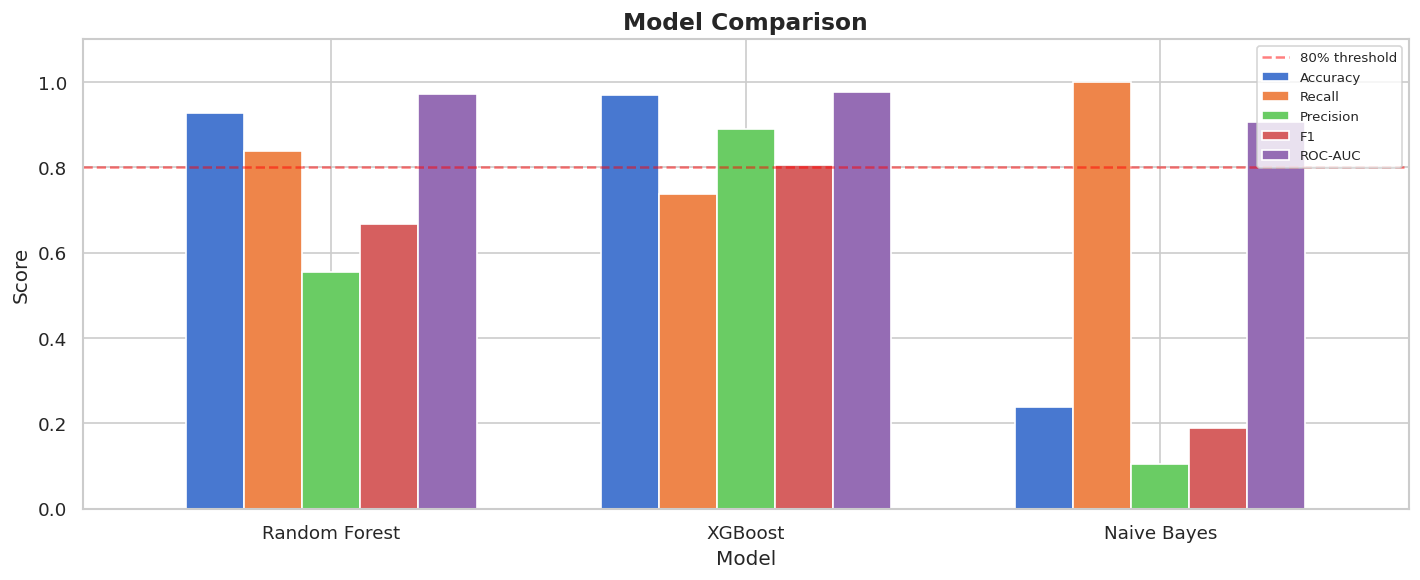

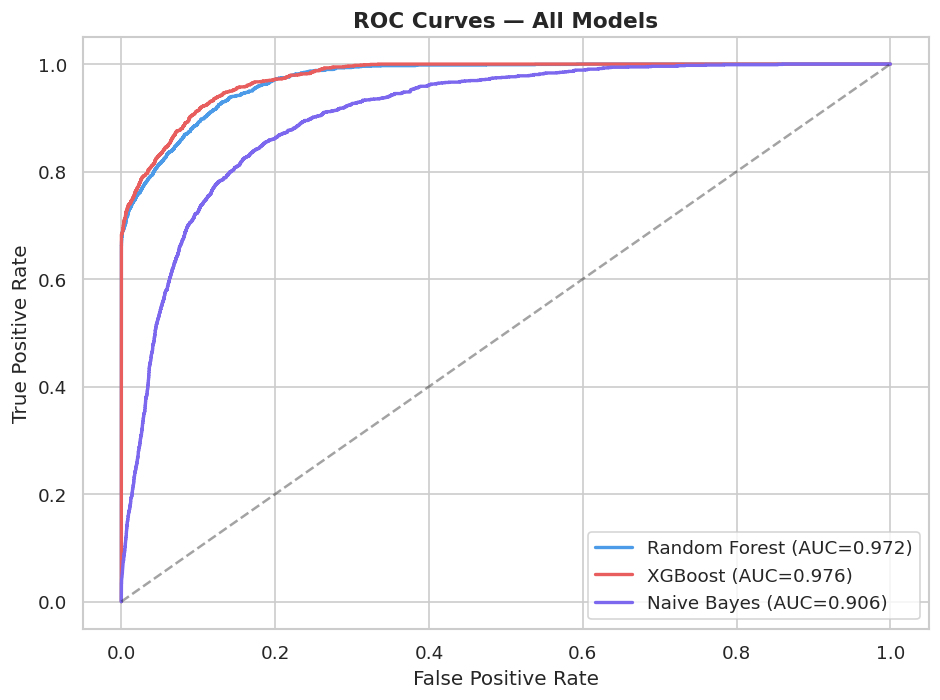

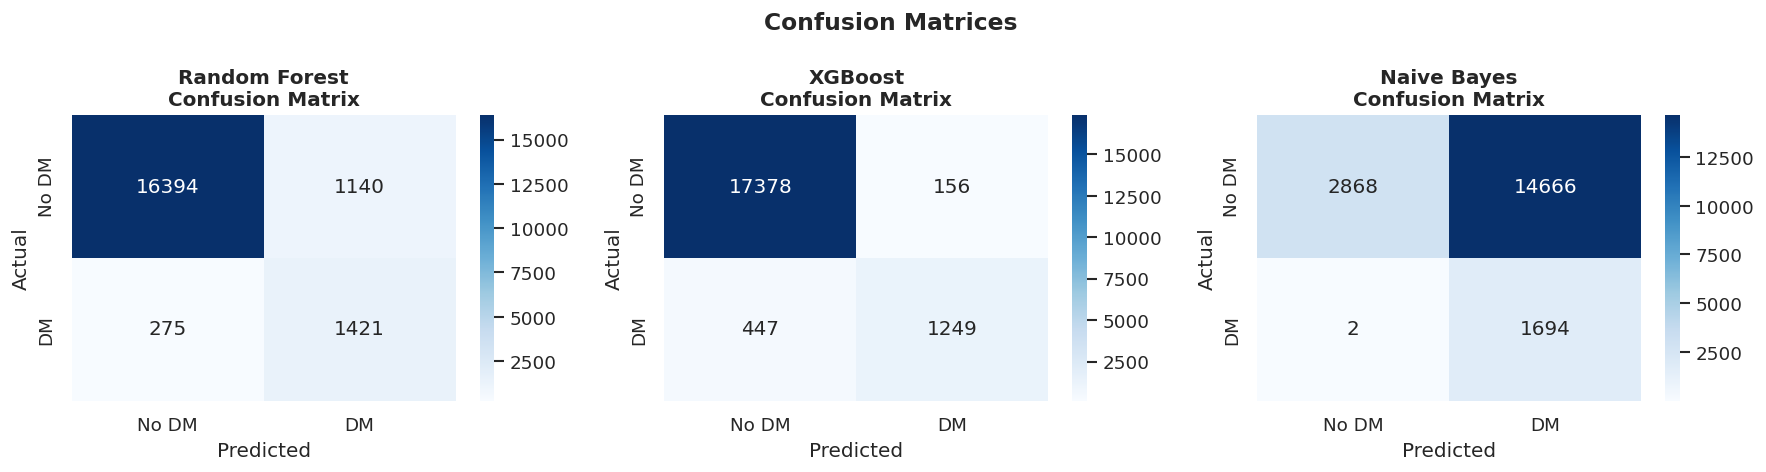

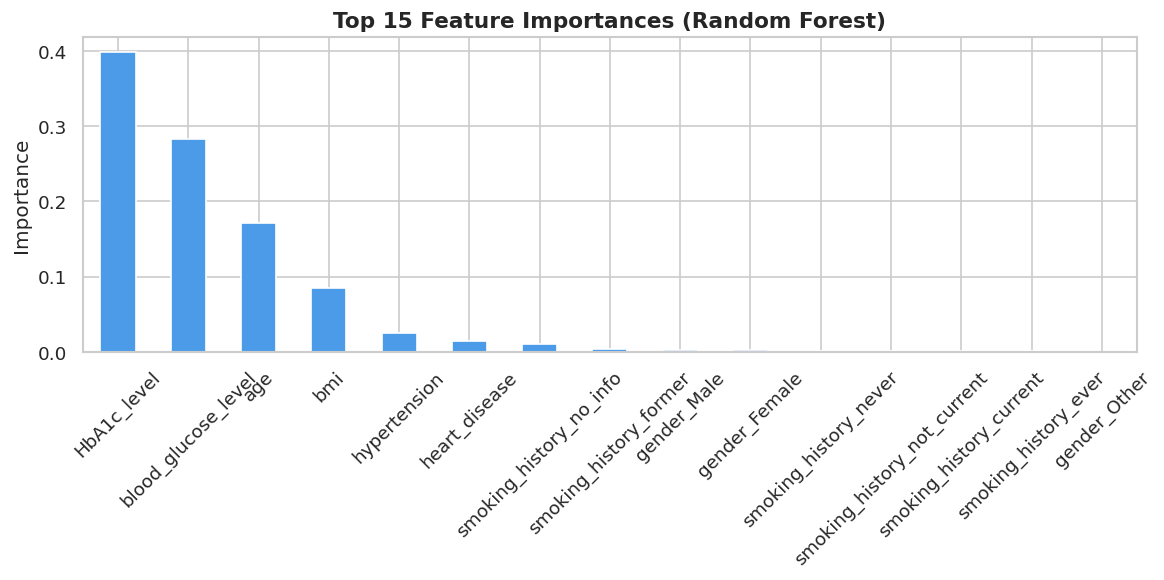

In [12]:
models = {
    'Random Forest': (rf_model,  y_pred_rf,  y_prob_rf),
    'XGBoost':       (xgb_model, y_pred_xgb, y_prob_xgb),
    'Naive Bayes':   (nb_model,  y_pred_nb,  y_prob_nb),
}

results = []
for name, (_, y_pred, y_prob) in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
results_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.axhline(0.8, ls='--', color='red', alpha=0.5, label='80% threshold')
ax.legend(loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C9BE8', '#E85D5D', '#7B68EE']
for (name, (_, _, y_prob)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, (_, y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No DM', 'DM'],
                yticklabels=['No DM', 'DM'])
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance (RF)
importances = pd.Series(rf_model.feature_importances_,
                         index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importances.head(15).plot(kind='bar', ax=ax, color='#4C9BE8', edgecolor='white')
ax.set_title('Top 15 Feature Importances (Random Forest)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Save Best Model & Artefacts

In [13]:
# Best model = highest ROC-AUC
best_name = results_df['ROC-AUC'].idxmax()
best_model = models[best_name][0]
print(f'Best model: {best_name}')

joblib.dump(best_model,    'best_model.pkl')
joblib.dump(rf_model,      'rf_model.pkl')
joblib.dump(xgb_model,     'xgb_model.pkl')
joblib.dump(nb_model,      'nb_model.pkl')
joblib.dump(scaler,        'scaler.pkl')
joblib.dump(feature_names, 'feature_names.pkl')

print('✅ Models and scaler saved')

Best model: XGBoost
✅ Models and scaler saved
